##  **YOLOv7: Real-time Vehicle Counting and Tracking**

🚗 This project aims to build a **vehicle counting and tracking system** using **YOLOv7**, a fast and accurate object detection model.

---

###  **Dataset Overview**

The dataset contains **50,000+ high-resolution images** from **1,000+ Indian cities**, covering:

1.Cars  
2.Trucks  
3.Buses  
4.Two-wheelers  
5.Tractors  
6.Auto-rickshaws  

Captured in **diverse conditions** — lighting, angles, and environments.

---

###**Data Preprocessing**

- Resizing images to a standard size (e.g., **640×640**)  
- Annotating bounding boxes for all vehicles  
- Applying data augmentation:
  - Rotation  
  - Flipping  
  - Brightness adjustment  
- Splitting dataset into **training** and **validation** sets

---

###**Training Setup**

- Define image size, batch size, learning rate, and number of epochs  
- Use **pretrained YOLOv7 weights (`best.pt`)** for faster convergence  
- Configure dataset and model structure via `.yaml` files

---

### **Objective**

Develop a model capable of:

- Real-time vehicle **detection**  
- Continuous **tracking**  
- Accurate **counting**

###**Detection + Tracking Integration**

-  YOLOv7 performs **real-time object detection** on each video frame.  
-  The output (bounding boxes, confidence scores, class IDs) is passed to a tracking module.  
-  Tracking allows the system to **maintain identity of vehicles** across frames using unique IDs.

---

### **SORT Tracking Algorithm**

- SORT (Simple Online and Realtime Tracking) is used to **track detected objects frame-by-frame**.
- Combines **Kalman Filter** (for motion prediction) with **Hungarian Algorithm** (for assignment).
-  Each vehicle is assigned a unique ID and tracked throughout its path.
- Helps with:
  - Detecting when vehicles cross ROI lines  
  - Counting in/out flow



**This notebook demonstrates model building**

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dataclusterlabs/indian-vehicle-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/dataclusterlabs/indian-vehicle-dataset/versions/5


In [10]:
import os

# Base folder where version 5 is stored
version_5_path = "/root/.cache/kagglehub/datasets/dataclusterlabs/indian-vehicle-dataset/versions/5"

print("Listing contents of version_5_path:")
print(os.listdir(version_5_path))

# Try the dataset folder inside version_5_path
dataset_folder = os.path.join(version_5_path, "Indian_vehicle_dataset")
if os.path.exists(dataset_folder):
    print(f"✅ Found dataset folder: {dataset_folder}")
    print(os.listdir(dataset_folder)[:10])  # show first 10 files/folders
else:
    print("❌ Dataset folder not found inside versions/5")


Listing contents of version_5_path:
['Indian_vehicle_dataset']
✅ Found dataset folder: /root/.cache/kagglehub/datasets/dataclusterlabs/indian-vehicle-dataset/versions/5/Indian_vehicle_dataset
['20210602_12_46_43_000_ni89GhC73POtfgv4i07JwfT2INu2_T_3000_4000.xml', '20210512_16_02_16_000_bsfUf1M1E9bMsvY4ENiWwUWjDQp2_F_4160_3120.jpg', '20210601_16_13_15_000_zHoQeOyp7mdLuEtqjxGYqdO2Bnn2_F_4160_3120.jpg', '20210530_06_07_18_000_IgrGpcUr9VUkCKoJXEc6qmRsBQQ2_F_4000_3000.xml', 'Datacluster Truck (19).jpg', '20210516_05_05_05_000_OgfflYWVtcZg5UlVKsTtIh0krh83_F_4016_3008.xml', '20210511_17_52_05_000_OgfflYWVtcZg5UlVKsTtIh0krh83_F_4016_3008.jpg', '20210603_22_01_11_000_LyPHDueZ3fMvhrNOCIasRTPDJG12_F_3264_2448.jpg', '20210516_06_28_09_000_OgfflYWVtcZg5UlVKsTtIh0krh83_F_4016_3008.jpg', 'Datacluster Truck (4).jpg']


In [11]:
# List all files in the dataset directory
all_files = os.listdir(version_5_path)

In [12]:
dataset_folder = os.path.join(version_5_path, "Indian_vehicle_dataset")
all_files = os.listdir(dataset_folder)

image_files = [f for f in all_files if f.lower().endswith(".jpg")]
xml_files = [f for f in all_files if f.lower().endswith(".xml")]

print(f" Found {len(image_files)} image(s)")
print(f" Found {len(xml_files)} annotation(s)")
print(" Sample image file:", image_files[:3])
print(" Sample XML file:", xml_files[:3])


 Found 100 image(s)
 Found 100 annotation(s)
 Sample image file: ['20210512_16_02_16_000_bsfUf1M1E9bMsvY4ENiWwUWjDQp2_F_4160_3120.jpg', '20210601_16_13_15_000_zHoQeOyp7mdLuEtqjxGYqdO2Bnn2_F_4160_3120.jpg', 'Datacluster Truck (19).jpg']
 Sample XML file: ['20210602_12_46_43_000_ni89GhC73POtfgv4i07JwfT2INu2_T_3000_4000.xml', '20210530_06_07_18_000_IgrGpcUr9VUkCKoJXEc6qmRsBQQ2_F_4000_3000.xml', '20210516_05_05_05_000_OgfflYWVtcZg5UlVKsTtIh0krh83_F_4016_3008.xml']


Image path exists: True


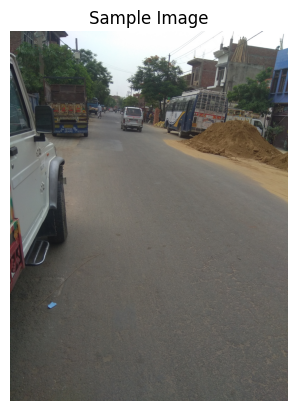

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

# Pick one sample image to preview
sample_image_path = os.path.join(dataset_folder, image_files[0])
print("Image path exists:", os.path.exists(sample_image_path))

img = Image.open(sample_image_path)
plt.imshow(img)
plt.axis("off")
plt.title("Sample Image")
plt.show()


In [21]:
import os
from shutil import copyfile, rmtree
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split

# === Paths ===
base_path = "/root/.cache/kagglehub/datasets/dataclusterlabs/indian-vehicle-dataset/versions/5/Indian_vehicle_dataset"
output_path = "/content/yolo_dataset"

# === Remove old dataset if exists ===
if os.path.exists(output_path):
    rmtree(output_path)

# === Create required folders ===
for split in ["train", "val"]:
    os.makedirs(os.path.join(output_path, f"images/{split}"), exist_ok=True)
    os.makedirs(os.path.join(output_path, f"labels/{split}"), exist_ok=True)

# === YOLO Classes ===
classes = [
    "Indian Auto", "Indian Truck", "Bus", "Truck", "Tempo Traveller",
    "Tractor", "Car", "Two Wheeler"
]

# === Mapping alternative class names to your class list ===
class_map = {
    "auto": "Indian Auto",
    "indian auto": "Indian Auto",
    "car": "Car",
    "bus": "Bus",
    "truck": "Truck",
    "vehicle_truck": "Indian Truck",
    "tempo traveller": "Tempo Traveller",
    "tempo": "Tempo Traveller",
    "tractor": "Tractor",
    "two_wheelers": "Two Wheeler",
    "two wheeler": "Two Wheeler",
    "bicycle": "Two Wheeler",
    "truck_tanker": "Truck",
    "concrete_mixer": "Truck"

}

# === Get list of image files ===
image_files = [f for f in os.listdir(base_path) if f.lower().endswith((".jpg", ".jpeg"))]
train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42)

# === Convert XML annotation to YOLO format ===
def convert_annotation(xml_file, output_txt_path, img_w, img_h):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    lines = []

    for obj in root.findall("object"):
        raw_cls = obj.find("name").text.strip().lower()
        mapped_cls = class_map.get(raw_cls)

        if mapped_cls not in classes:
            print(f" Unknown or unmapped class '{raw_cls}' in {os.path.basename(xml_file)}")
            continue

        cls_id = classes.index(mapped_cls)

        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    if lines:
        with open(output_txt_path, "w") as f:
            f.write("\n".join(lines))

# === Prepare dataset (copy images + labels) ===
def prepare_dataset(image_list, split):
    for img_name in image_list:
        img_src = os.path.join(base_path, img_name)
        img_dst = os.path.join(output_path, "images", split, img_name)
        copyfile(img_src, img_dst)

        xml_name = os.path.splitext(img_name)[0] + ".xml"
        xml_src = os.path.join(base_path, xml_name)

        if not os.path.exists(xml_src):
            print(f"Missing annotation: {xml_name}")
            continue

        try:
            tree = ET.parse(xml_src)
            root = tree.getroot()
            width = int(root.find("size/width").text)
            height = int(root.find("size/height").text)
        except Exception as e:
            print(f"Error parsing {xml_src}: {e}")
            continue

        label_dst = os.path.join(output_path, "labels", split, xml_name.replace(".xml", ".txt"))
        convert_annotation(xml_src, label_dst, width, height)

# === Run preprocessing ===
prepare_dataset(train_imgs, "train")
prepare_dataset(val_imgs, "val")

print(f"Dataset prepared at: {output_path}")

# === Create data.yaml for YOLOv7 ===
data_yaml = f"""
train: {output_path}/images/train
val: {output_path}/images/val

nc: {len(classes)}
names: {classes}
"""

yaml_path = "/content/yolov7/data.yaml"
os.makedirs(os.path.dirname(yaml_path), exist_ok=True)
with open(yaml_path, "w") as f:
    f.write(data_yaml.strip())

print(f"data.yaml created at {yaml_path}")


Dataset prepared at: /content/yolo_dataset
data.yaml created at /content/yolov7/data.yaml


In [16]:
#deleting clone
!rm -rf yolov7
!git clone https://github.com/WongKinYiu/yolov7.git
%cd yolov7



Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 32.14 MiB/s, done.
Resolving deltas: 100% (513/513), done.
/content/yolov7


In [8]:
'''!rm -rf yolov7
!git clone https://github.com/WongKinYiu/yolov7.git

%cd /content/yolov7'''

'!rm -rf yolov7\n!git clone https://github.com/WongKinYiu/yolov7.git\n\n%cd /content/yolov7'

In [17]:
#Clone YOLOv7 repo and install requirements
!git clone https://github.com/WongKinYiu/yolov7.git
%cd /content/yolov7



Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 34.94 MiB/s, done.
Resolving deltas: 100% (513/513), done.
/content/yolov7


In [18]:
!ls


cfg	   export.py   LICENSE.md  requirements.txt  train_aux.py
data	   figure      models	   scripts	     train.py
deploy	   hubconf.py  paper	   test.py	     utils
detect.py  inference   README.md   tools	     yolov7


In [19]:
#Downloading pretrained weights
!wget https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt -P /content/yolov7/

--2025-08-19 15:39:02--  https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/511187726/b0243edf-9fb0-4337-95e1-42555f1b37cf?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-08-19T16%3A34%3A49Z&rscd=attachment%3B+filename%3Dyolov7.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-08-19T15%3A34%3A26Z&ske=2025-08-19T16%3A34%3A49Z&sks=b&skv=2018-11-09&sig=%2BUEZLyTtEEXbKD5ztoGwQRXTTrJxJiai4yixxMKrB44%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1NTYxODI0MiwibmJmIjoxNzU1NjE3OTQyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2lu

In [12]:
!pip install -r requirements.txt


INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.9 MB/s eta 0:00:00
   ━━

In [2]:
!pip uninstall -y torch torchvision torchaudio numpy
!pip install torch==2.1.1 torchvision==0.16.1 numpy==1.26.4


Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823

In [18]:
!pip uninstall -y tensorflow tensorboard

In [19]:
!pip install tensorflow==2.12.0 tensorboard==2.12.0

  Using cached tensorboard-2.12.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached gast-0.4.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached jax-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached keras-2.12.0-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached tensorflow_estimator-2.12.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached google_auth_oauthlib-0.4.6-py2.py3-none-any.whl.metadata (2.7 kB)
  Using cached tensorboard_plugin_wit-1.8.1-py3-none-any.whl.metadata (873 bytes)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
  Using cached jax-0.6.1-py3-none-any.whl.metadata (13 kB)
  Using cached jax-0.6.0-py3-none-any.whl.metadata (22 kB)
  Using cached jax-0.5.2-py3-none-any.whl.metadata (22 kB)
  Using cached jax-0.5.1-py3-none-any.whl.metadata (22 kB)
  Using cached jax-0.5.0-py3-none-an

In [1]:
!pip install torch==2.0.0 torchvision==0.15.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.1.1 torchvision==0.16.1 torchaudio==2.1.1 --index-url https://download.pytorch.org/whl/cu121


Found existing installation: torchvision 0.15.1
Uninstalling torchvision-0.15.1:
  Successfully uninstalled torchvision-0.15.1
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 546.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 78.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 95.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 9.1 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 2.0.0
    Uninstalling triton-2.0.0:
      Successfully uninstalled triton-2.0.0


In [10]:
#rm -rf yolov7/yolov7/yolov7
/content/yolov7/train.py

In [13]:
# Colab-specific Python 3.10 downgrade
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-distutils -y
!wget https://bootstrap.pypa.io/get-pip.py
!python3.10 get-pip.py
!python3.10 -m pip install --upgrade pip setuptools wheel

# Use pip to install compatible versions
!python3.10 -m pip install torch==1.13.1 torchvision==0.14.1


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,937 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,189 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,271 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubu

In [16]:
!pip install pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.2/751.2 kB 22.5 MB/s  0:00:00


In [21]:
!pip install tqdm


In [2]:
!pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 135.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pandas]


In [4]:
!pip install opencv-python


  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 63.1 MB/s  0:00:01
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 117.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]


In [2]:
%env MPLBACKEND=Agg


env: MPLBACKEND=Agg


In [24]:
!pip install numpy==1.24.4 --force-reinstall


  Using cached numpy-1.24.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.24.4 which is incompatible.
tensorflow 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.24.4 which is incompatible.


In [7]:
!pip install seaborn

In [4]:
#Deleted duplicate
!rm -rf /content/yolov7/yolov7


In [6]:
!find /content/yolov7 -name 'hyp.scratch.p5.yaml'


/content/yolov7/data/hyp.scratch.p5.yaml


In [10]:
!python3.10 /content/yolov7/train.py \
  --data /content/yolov7/data.yaml \
  --cfg /content/yolov7/cfg/training/yolov7.yaml \
  --weights /content/yolov7/yolov7.pt \
  --device 0 \
  --epochs 100 \
  --batch-size 16


YOLOR 🚀 v0.1-128-ga207844 torch 1.13.1+cu117 CUDA:0 (Tesla T4, 15095.0625MB)

Namespace(weights='/content/yolov7/yolov7.pt', cfg='/content/yolov7/cfg/training/yolov7.yaml', data='/content/yolov7/data.yaml', hyp='./yolov7/data/hyp.scratch.p5.yaml', epochs=100, batch_size=16, img_size=[640, 640], rect=False, resume=False, nosave=False, notest=False, noautoanchor=False, evolve=False, bucket='', cache_images=False, image_weights=False, device='0', multi_scale=False, single_cls=False, adam=False, sync_bn=False, local_rank=-1, workers=8, project='runs/train', entity=None, name='exp', exist_ok=False, quad=False, linear_lr=False, label_smoothing=0.0, upload_dataset=False, bbox_interval=-1, save_period=-1, artifact_alias='latest', freeze=[0], v5_metric=False, world_size=1, global_rank=-1, save_dir='runs/train/exp4', total_batch_size=16)
tensorboard: Start with 'tensorboard --logdir runs/train', view at http://localhost:6006/
2025-08-19 16:08:19.873015: I tensorflow/core/platform/cpu_feature_gua

In [12]:
from google.colab import files
files.download('runs/train/exp4/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from google.colab import files
files.download('runs/train/exp4/weights/last.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>